In [1]:
import matplotlib.pyplot as plt
plt.style.use('thesis')
import numpy as np

In [9]:
base = '/avatar/vmehta/sfh_500_10bins_20260427_112623/finalmodel/train_sfh_1100_6bins_20260423_112538_snr100__test_sfh_500_10bins_20260427_112623_snr100'
spec6 = np.load('/home/vmehta/honours-project/code/data/sfh_sixbins_spectra.npy')
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tenbins_spectra.npy')
pred = np.load(f'{base}_pred.npy')
true = np.load(f'{base}_true.npy')

In [22]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm6 = [normalize(spec) for spec in spec6]
norm10 = [normalize(spec) for spec in spec10]

pred_spec = pred @ norm6
true_spec = true @ norm10

In [32]:
young = []
mixed = []
old = []

for n, i in enumerate(true):
    if np.sum(i[-2:]) > 0.5:
        old.append(n)
    elif np.sum(i[:4]) > 0.5:
        young.append(n)
    else:
        mixed.append(n)

In [69]:
edges6 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 6)])
centers6 = (edges6[:-1] + edges6[1:]) / 2
widths6 = edges6[1:] - edges6[:-1]
edges10 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 10)])
centers10 = (edges10[:-1] + edges10[1:]) / 2
widths10 = edges10[1:] - edges10[:-1]

In [106]:
old

[42,
 44,
 46,
 49,
 57,
 64,
 81,
 92,
 93,
 94,
 99,
 142,
 148,
 149,
 161,
 183,
 192,
 194,
 198,
 199,
 228,
 242,
 243,
 244,
 247,
 293,
 297,
 298,
 308,
 325,
 343,
 344,
 349,
 374,
 377,
 388,
 392,
 393,
 394,
 398,
 399,
 443,
 445,
 448,
 492,
 493,
 494,
 499]

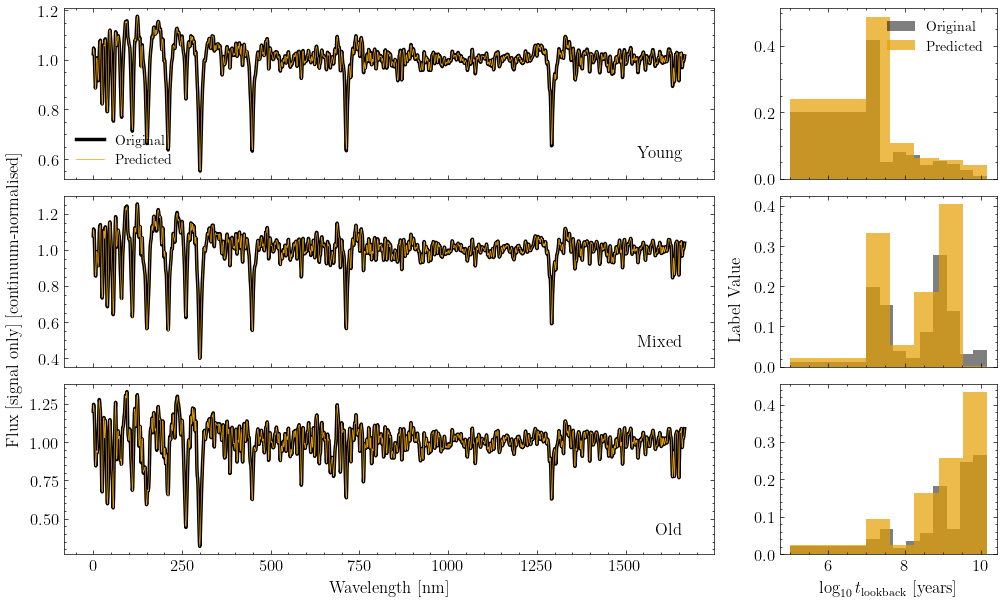

In [109]:
a = 59
b = 32
c = 183

fig, ax = plt.subplots(3, 2, figsize=(10, 6), sharex='col', constrained_layout=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.08})

ax[0, 0].plot(true_spec[a], 'k', linewidth=2.5, label='Original')
ax[0, 0].plot(pred_spec[a], 'C0', linewidth=0.5, label='Predicted')
ax[0, 0].legend(fontsize=10, loc='lower left')
ax[0,0].text(0.95, 0.1, 'Young', transform=ax[0, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[0, 1].bar(centers10, true[a], width=widths10, color='k', alpha=0.5, label='Original')
ax[0, 1].bar(centers6, pred[a], width=widths6, color='C0', alpha=0.7, label='Predicted')
ax[0, 1].legend(fontsize=10, loc='upper right')

ax[1, 0].plot(true_spec[b], 'k', linewidth=2.5, label='Original')
ax[1, 0].plot(pred_spec[b], 'C0', linewidth=0.5, label='Predicted')
ax[1, 0].text(0.95, 0.1, 'Mixed', transform=ax[1, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[1, 1].bar(centers10, true[b], width=widths10, color='k', alpha=0.5, label='Original')
ax[1, 1].bar(centers6, pred[b], width=widths6, color='C0', alpha=0.7, label='Predicted')

ax[2, 0].plot(true_spec[c], 'k', linewidth=2.5, label='Original')
ax[2, 0].plot(pred_spec[c], 'C0', linewidth=0.5, label='Predicted')
ax[2, 0].text(0.95, 0.1, 'Old', transform=ax[2, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
ax[2, 0].set_xlabel('Wavelength [nm]', fontsize=12)

ax[2, 1].bar(centers10, true[c], width=widths10, color='k', alpha=0.5, label='Original')
ax[2, 1].bar(centers6, pred[c], width=widths6, color='C0', alpha=0.7, label='Predicted')
ax[2, 1].set_xlabel(f'$\\log_{{10}}t_\\mathrm{{lookback}}$ [years]', fontsize=12)

fig.supylabel('Flux [signal only] [continuum-normalised]', fontsize=12)
fig.text(0.735, 0.5, 'Label Value', va='center', ha='center', rotation='vertical', fontsize=12)

plt.savefig('/home/vmehta/honours-project/thesis/figures/mismatched.pdf', format='pdf')
plt.show()